# Loading, cleaning and displaying gas exchange data

This is an example of how to load, clean and display gas exchange data from a Licor-6800 file. \
More information about the symbols can be found here: \
https://www.licor.com/support/LI-6800/topics/symbols.html#GasEx

Load some libraries for data processing and plotting.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Optional: Set the style for prettier plots
plt.style.use('seaborn-v0_8-whitegrid')

This function reads the data while accounting for the data structure.

In [ ]:
def load_gas_exchange_file(filepath):
    """
    Parses the custom text file, skips the header, deduplicates column names, 
    and extracts the data.
    """
    with open(filepath, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()
        
    data_idx = -1
    for i, line in enumerate(lines):
        if line.strip() == '[Data]':
            data_idx = i
            break
            
    if data_idx == -1:
        print(f"Skipping {filepath} - No '[Data]' tag found.")
        return None
        
    # Extract raw column names
    raw_col_names = lines[data_idx + 2].strip('\n').split('\t')
    
    # Deduplicate column names (e.g., turn duplicate "TIME" into "TIME_1")
    col_names = []
    seen_names = {}
    
    for name in raw_col_names:
        # Handle trailing tabs which create empty strings
        if not name.strip():
            name = "Unnamed"
            
        if name in seen_names:
            seen_names[name] += 1
            col_names.append(f"{name}_{seen_names[name]}")
        else:
            seen_names[name] = 0
            col_names.append(name)
    
    # Read the data into a pandas DataFrame
    try:
        df = pd.read_csv(
            filepath, 
            sep='\t', 
            skiprows=data_idx + 4, 
            names=col_names, 
            index_col=False,
            engine='python' 
        )
        # Drop empty columns
        df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
        return df
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return None

Here you can change the directory you want to load.
It loads all the data files of the directory into a dictionary. \
The data is cleaned by removing outliers or other problems. \
During self-calibration (detected by LeakPct > 1) the instrument continue to record but the data is not valid. \
Some cleaning steps are necessary to remove other types of invalid points (gsw values that are outside realistic values).

In [ ]:
# Set your directory path here. Use '.' for the current directory.
DIRECTORY = 'Data/Training' 

# Define your quality control thresholds
leak_threshold = 1.0
gs_min = 0.0
gs_max = 0.6

data_dict = {}

# Iterate over files in the directory
for filename in os.listdir(DIRECTORY):
    filepath = os.path.join(DIRECTORY, filename)
    
    # Check if it's a file and has no extension
    if os.path.isfile(filepath) and '.' not in filename:
        df = load_gas_exchange_file(filepath)
        
        if df is not None and not df.empty:
            initial_len = len(df)
            
            # --- CLEANING STEP 1: LEAK ---
            if 'LeakPct' in df.columns:
                df['Leak'] = pd.to_numeric(df['LeakPct'], errors='coerce')
                df = df[df['Leak'] <= leak_threshold]
            else:
                print(f"Warning: 'LeakPct' column not found in {filename}.")
                
            # --- CLEANING STEP 2: STOMATAL CONDUCTANCE (gsw) ---
            gs_col = 'gsw' if 'gsw' in df.columns else ('gs' if 'gs' in df.columns else None)
            if gs_col:
                df[gs_col] = pd.to_numeric(df[gs_col], errors='coerce')
                df = df[(df[gs_col] >= gs_min) & (df[gs_col] <= gs_max)]
            else:
                print(f"Warning: Neither 'gsw' nor 'gs' column found in {filename}.")
            
            dropped_rows = initial_len - len(df)
            
            # Only add to dictionary if there's still data left after cleaning
            if not df.empty:
                data_dict[filename] = df
                print(f"Loaded & Cleaned: {filename} ({len(df)} rows kept, {dropped_rows} dropped).")
            else:
                print(f"Skipping {filename}: All rows were filtered out during cleaning.")

if not data_dict:
    print("No valid files found, or all data was filtered out.")

Loaded & Cleaned: 2023-09-06-1204_logdata_silvere2_flash (5655 rows kept, 30 dropped).
Loaded & Cleaned: 2023-08-30-1101_logdata_silvere2_flash (5638 rows kept, 33 dropped).
Loaded & Cleaned: 2023-08-25-1038_logdata_silvere2_flash (5642 rows kept, 46 dropped).
Loaded & Cleaned: 2023-10-24-1257_logdata_silvere2_flash (5602 rows kept, 67 dropped).
Loaded & Cleaned: 2023-10-24-1300_logdata2_silvere2_flash (5538 rows kept, 30 dropped).
Loaded & Cleaned: 2023-09-22-1242_logdata_silvere2_flash (5598 rows kept, 44 dropped).


Display the cleaned data. You can visually inspect the data and start thinking about a model :-D

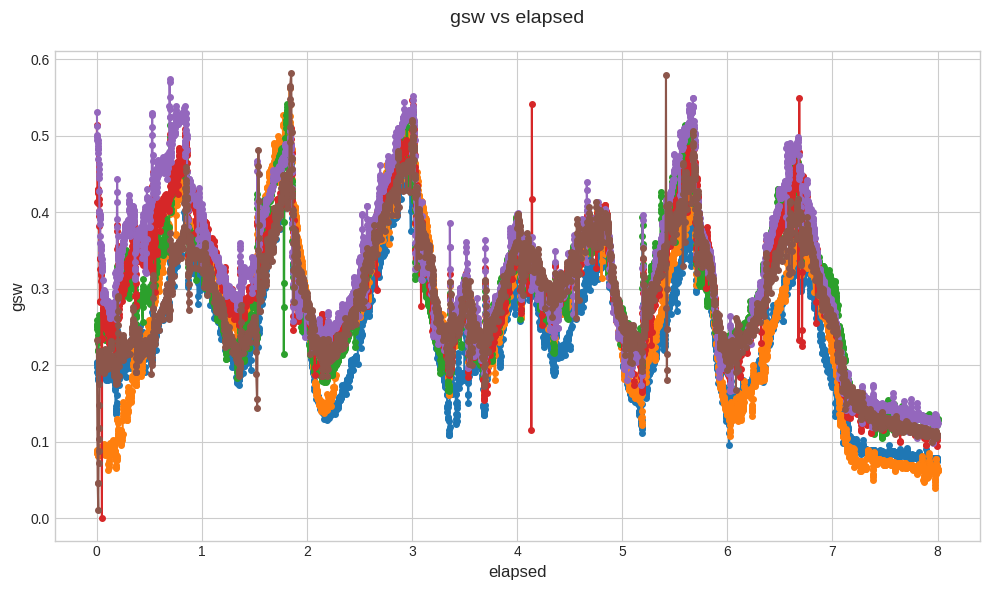

In [ ]:
# Define which columns to plot
x_col = 'elapsed'
y_col = 'gsw'

plt.figure(figsize=(10, 6))

for filename, df in data_dict.items():
    if x_col in df.columns and y_col in df.columns:
        
        # Convert plotting columns to numeric (just in case)
        x_data = pd.to_numeric(df[x_col], errors='coerce')
        y_data = pd.to_numeric(df[y_col], errors='coerce')
        
        # Plot the pre-cleaned data
        plt.plot(x_data/3600, y_data, marker='o', linestyle='-', markersize=4, label=filename)
    else:
        print(f"Warning: Columns '{x_col}' or '{y_col}' not found in {filename}.")

# We can still reference the thresholds in the title since they were defined in Cell 3
plt.title(f'{y_col} vs {x_col}\n', fontsize=14)
plt.xlabel(f'{x_col}', fontsize=12)
plt.ylabel(f'{y_col}', fontsize=12)
#plt.legend(title="Files", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()